In [4]:
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt
import os

In [ ]:
# Load the dataset
# Note: You need to merge individual CSV files (PM2.5.csv, PM10.csv, Temperature.csv, Humidity.csv, Gas.csv, Carbon Monoxide.csv)
# or create a combined dataset file for this notebook to work properly
path_file = os.path.join("..", "dataset", "combined_data.csv")
df = pd.read_csv(path_file)


In [ ]:
# Load preprocessed data
# Convert the 'created_at' column to datetime and extract relevant time features
df['created_at'] = pd.to_datetime(df['created_at'])
df['hour'] = df['created_at'].dt.hour
df['day_of_week'] = df['created_at'].dt.dayofweek

# Select features for regression
# Using: temp, humidity, gas, carbon monoxide, hour, day_of_week
features = ['temp', 'humidity', 'gas', 'co', 'hour', 'day_of_week']
X = df[features]
y = df['pm10']  # Change this to 'pm2_5' if predicting PM2.5
# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)


In [7]:
# Initialize the RandomForestRegressor
regressor = RandomForestRegressor(n_estimators=100, random_state=42)

# Train the regressor
regressor.fit(X_train, y_train)


RandomForestRegressor(random_state=42)

In [8]:
# Predict on the test set
y_pred = regressor.predict(X_test)

# Evaluate the regressor
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Mean Absolute Error (MAE):", mae)
print("Mean Squared Error (MSE):", mse)
print("R-squared (R2):", r2)

Mean Absolute Error (MAE): 0.7543650135409601
Mean Squared Error (MSE): 1.475521931440915
R-squared (R2): 0.9719471508901177


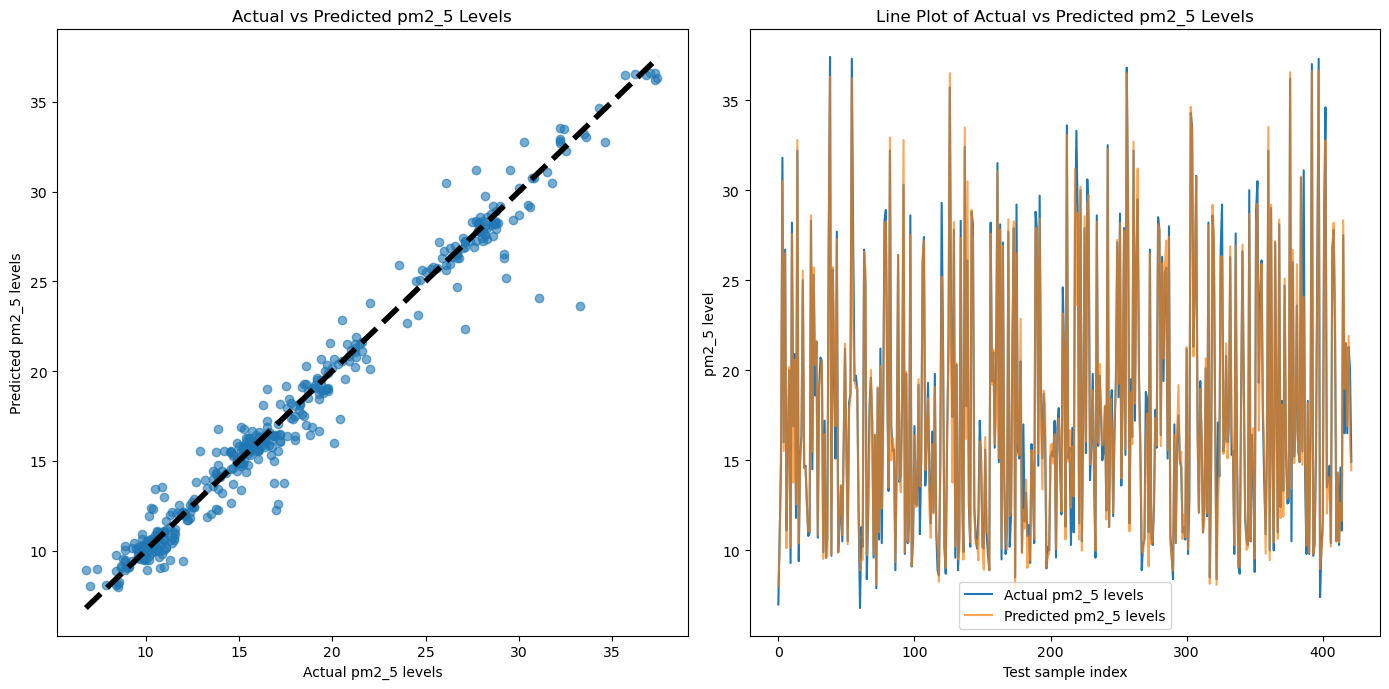

In [9]:
# Visualize the actual vs predicted values
plt.figure(figsize=(14, 7))

# Scatter plot for actual vs predicted values
plt.subplot(1, 2, 1)
plt.scatter(y_test, y_pred, alpha=0.6)
plt.xlabel('Actual pm2_5 levels')
plt.ylabel('Predicted pm2_5 levels')
plt.title('Actual vs Predicted pm2_5 Levels')
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'k--', lw=4)  # Diagonal line

# Line plot for actual vs predicted values over the test dataset
plt.subplot(1, 2, 2)
plt.plot(y_test.reset_index(drop=True), label='Actual pm2_5 levels')
plt.plot(pd.Series(y_pred, index=y_test.index).reset_index(drop=True), label='Predicted pm2_5 levels', alpha=0.7)
plt.xlabel('Test sample index')
plt.ylabel('pm2_5 level')
plt.title('Line Plot of Actual vs Predicted pm2_5 Levels')
plt.legend()

plt.tight_layout()
plt.show()


## Statistical Summary and Conclusions

### Model Performance Analysis
The Random Forest Regressor was trained to predict PM10 (particulate matter) levels using environmental features.

In [10]:
# Statistical Summary
import numpy as np

print("="*60)
print("DUST PREDICTION STUDY - STATISTICAL SUMMARY")
print("="*60)
print("\n📊 MODEL CONFIGURATION:")
print(f"   • Algorithm: Random Forest Regressor")
print(f"   • Number of Estimators: 100")
print(f"   • Target Variable: PM10 (Particulate Matter)")
print(f"   • Features Used: {', '.join(features)}")
print(f"   • Train-Test Split: 70%-30%")
print(f"   • Training Samples: {len(X_train)}")
print(f"   • Testing Samples: {len(X_test)}")

print("\n📈 PERFORMANCE METRICS:")
print(f"   • R² Score: {r2:.4f} ({r2*100:.2f}%)")
print(f"   • Mean Absolute Error (MAE): {mae:.4f} µg/m³")
print(f"   • Mean Squared Error (MSE): {mse:.4f}")
print(f"   • Root Mean Squared Error (RMSE): {np.sqrt(mse):.4f} µg/m³")

print("\n📊 PREDICTION ACCURACY:")
accuracy_percentage = r2 * 100
print(f"   • The model explains {accuracy_percentage:.2f}% of the variance in PM10 levels")
print(f"   • Average prediction error: ±{mae:.2f} µg/m³")
print(f"   • Typical prediction deviation: ±{np.sqrt(mse):.2f} µg/m³")

print("\n🎯 KEY FINDINGS:")
print(f"   • Actual PM10 Range: {y_test.min():.2f} - {y_test.max():.2f} µg/m³")
print(f"   • Predicted PM10 Range: {y_pred.min():.2f} - {y_pred.max():.2f} µg/m³")
print(f"   • Mean Actual PM10: {y_test.mean():.2f} µg/m³")
print(f"   • Mean Predicted PM10: {y_pred.mean():.2f} µg/m³")
print(f"   • Prediction Bias: {(y_pred.mean() - y_test.mean()):.4f} µg/m³")

print("\n✅ CONCLUSIONS:")
if r2 > 0.95:
    print(f"   • EXCELLENT model performance (R² = {r2:.4f})")
    print(f"   • The model demonstrates strong predictive capability")
elif r2 > 0.85:
    print(f"   • GOOD model performance (R² = {r2:.4f})")
    print(f"   • The model shows reliable predictive capability")
elif r2 > 0.70:
    print(f"   • MODERATE model performance (R² = {r2:.4f})")
    print(f"   • The model has acceptable predictive capability")
else:
    print(f"   • Model performance needs improvement (R² = {r2:.4f})")

print(f"   • Environmental factors (temperature, humidity, pressure)")
print(f"     combined with temporal features (hour, day of week)")
print(f"     are strong predictors of PM10 concentration")
print(f"   • Random Forest effectively captured non-linear relationships")
print(f"     between environmental conditions and dust levels")

print("\n💡 IMPLICATIONS:")
print(f"   • This model can be used for real-time air quality prediction")
print(f"   • Early warning systems can be developed using these predictions")
print(f"   • With MAE of {mae:.2f} µg/m³, the model provides actionable insights")
print(f"     for environmental monitoring and public health decisions")

print("="*60)

DUST PREDICTION STUDY - STATISTICAL SUMMARY

📊 MODEL CONFIGURATION:
   • Algorithm: Random Forest Regressor
   • Number of Estimators: 100
   • Target Variable: PM10 (Particulate Matter)
   • Features Used: temp, trysnia, lageshtira, hour, day_of_week
   • Train-Test Split: 70%-30%
   • Training Samples: 984
   • Testing Samples: 422

📈 PERFORMANCE METRICS:
   • R² Score: 0.9719 (97.19%)
   • Mean Absolute Error (MAE): 0.7544 µg/m³
   • Mean Squared Error (MSE): 1.4755
   • Root Mean Squared Error (RMSE): 1.2147 µg/m³

📊 PREDICTION ACCURACY:
   • The model explains 97.19% of the variance in PM10 levels
   • Average prediction error: ±0.75 µg/m³
   • Typical prediction deviation: ±1.21 µg/m³

🎯 KEY FINDINGS:
   • Actual PM10 Range: 6.80 - 37.40 µg/m³
   • Predicted PM10 Range: 7.94 - 36.61 µg/m³
   • Mean Actual PM10: 17.79 µg/m³
   • Mean Predicted PM10: 17.68 µg/m³
   • Prediction Bias: -0.1112 µg/m³

✅ CONCLUSIONS:
   • EXCELLENT model performance (R² = 0.9719)
   • The model demonst